                IRIS FLOWER CLASSIFICATION


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Set visualization style for better looking plots
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

LOADING DATASET

In [2]:
# Load the iris dataset
iris = load_iris()

# Create a Pandas DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Add the target variable (the species) to the DataFrame
df['species'] = iris.target

# Map the numerical target (0, 1, 2) back to actual species names for readability
df['species'] = df['species'].map({
    0: 'setosa', 
    1: 'versicolor', 
    2: 'virginica'
})

# Display the first 5 rows to confirm it loaded correctly
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Data Types & Non-Null Counts ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum()) # Confirms there are no null values

print("\n--- Descriptive Statistics ---")
display(df.describe())

--- Dataset Shape ---
Rows: 150, Columns: 5

--- Data Types & Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- Missing Values ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

--- Descriptive Statistics ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


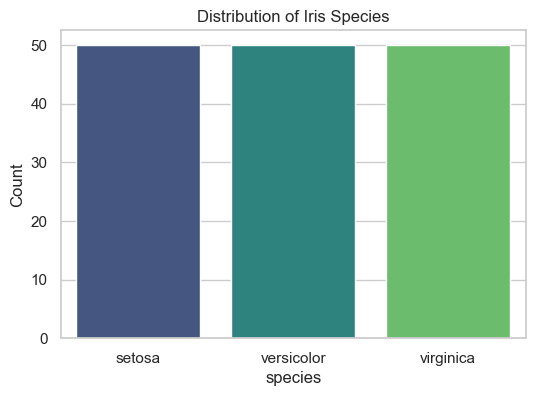

In [4]:
# Check how many samples exist for each species
class_counts = df['species'].value_counts()
print(class_counts)

# Visualize the distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Distribution of Iris Species')
plt.ylabel('Count')
plt.show()
# Note: You should see exactly 50 of each species.

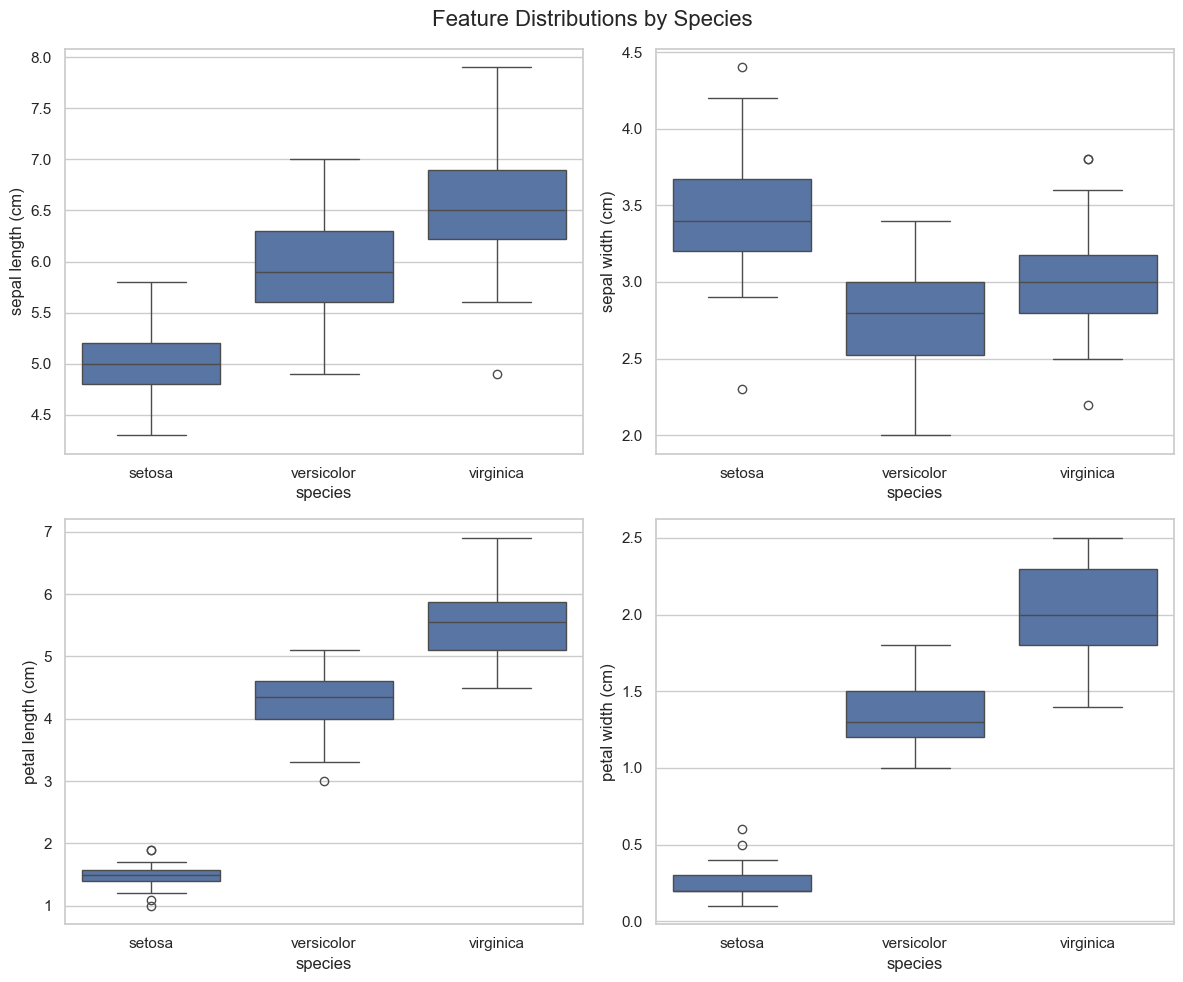

In [5]:
# Create a 2x2 grid of boxplots for the four features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Feature Distributions by Species', fontsize=16)

sns.boxplot(ax=axes[0, 0], x='species', y='sepal length (cm)', data=df)
sns.boxplot(ax=axes[0, 1], x='species', y='sepal width (cm)', data=df)
sns.boxplot(ax=axes[1, 0], x='species', y='petal length (cm)', data=df)
sns.boxplot(ax=axes[1, 1], x='species', y='petal width (cm)', data=df)

plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

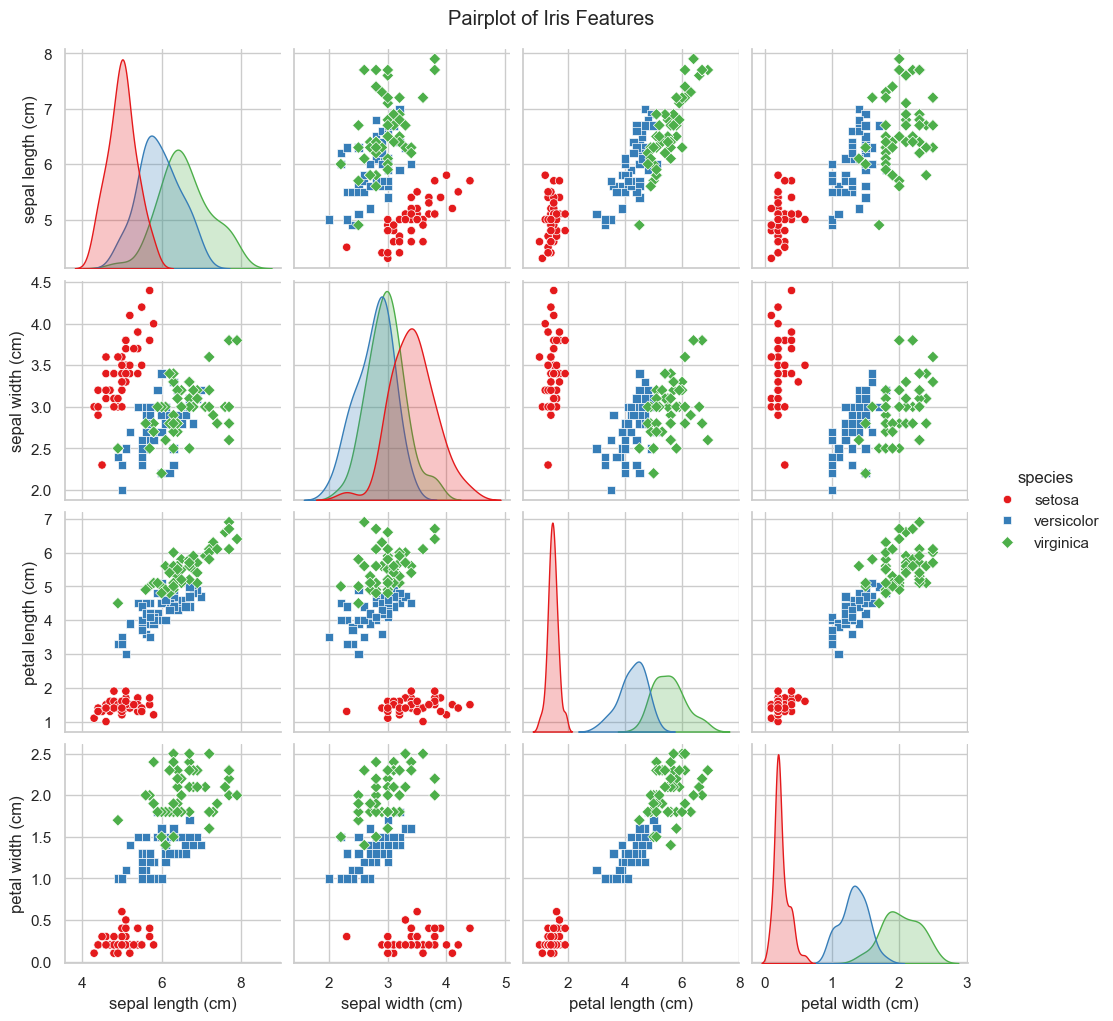

In [6]:
# Create a pairplot coloring the data points by species
plt.figure(figsize=(10, 8))
sns.pairplot(df, hue='species', markers=["o", "s", "D"], palette='Set1')
plt.suptitle("Pairplot of Iris Features", y=1.02)
plt.show()

# Key takeaway: Notice how 'setosa' is cleanly separated from the other two 
# species in almost every plot, especially those involving Petal Length and Width.

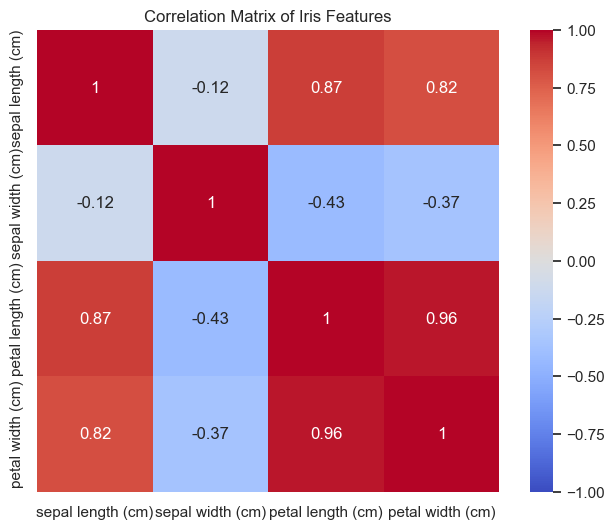

In [7]:
plt.figure(figsize=(8, 6))
# Calculate correlations (ignoring the 'species' string column)
correlation_matrix = df.drop('species', axis=1).corr()

# Plot the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Matrix of Iris Features')
plt.show()

# Key takeaway: Petal length and petal width have a near-perfect positive 
# correlation (0.96). Sepal width and sepal length are slightly negatively correlated.

In [8]:
# X contains the physical measurements (Features)
X = df.drop('species', axis=1)

# y contains the actual species names (Target)
y = df['species']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (150, 4)
Target (y) shape: (150,)


In [9]:
from sklearn.model_selection import train_test_split

# Split the data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, # Ensures we get the exact same split every time we run this
    stratify=y       # Ensures the 80/20 split has an equal mix of all 3 species
)

print(f"Training data size: {X_train.shape[0]} flowers")
print(f"Testing data size: {X_test.shape[0]} flowers")

Training data size: 120 flowers
Testing data size: 30 flowers


In [10]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the model
# max_iter=200 gives the algorithm enough time to find the best mathematical boundaries
log_reg = LogisticRegression(max_iter=200, random_state=42)

# 2. Train the model using our training data
log_reg.fit(X_train, y_train)

print("Model training complete! The algorithm has learned the patterns.")

Model training complete! The algorithm has learned the patterns.


In [11]:
# Generate predictions on the unseen test data
y_pred = log_reg.predict(X_test)

# Let's peek at the first 5 predictions vs the actual answers
comparison = pd.DataFrame({'Actual Species': y_test[:5], 'Predicted Species': y_pred[:5]})
display(comparison)

,Actual Species,Predicted Species
38,setosa,setosa
127,virginica,virginica
57,versicolor,versicolor
93,versicolor,versicolor
42,setosa,setosa


Overall Accuracy: 96.67%

--- Confusion Matrix ---


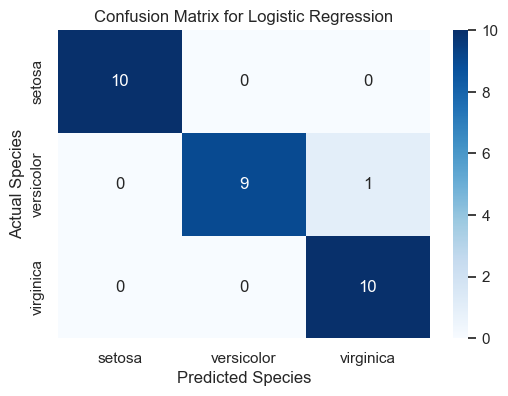


--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Overall Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {accuracy * 100:.2f}%\n")

# 2. Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
# Display it nicely using seaborn
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

# 3. Detailed Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

RANDOM FOREST

In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest model
# n_estimators=100 means we are building a "forest" of 100 decision trees
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
rf_clf.fit(X_train, y_train)

# 3. Generate predictions on the test set
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest training and prediction complete!")

Random Forest training and prediction complete!


========== RANDOM FOREST EVALUATION ==========

Overall Accuracy: 90.00%

--- Confusion Matrix ---


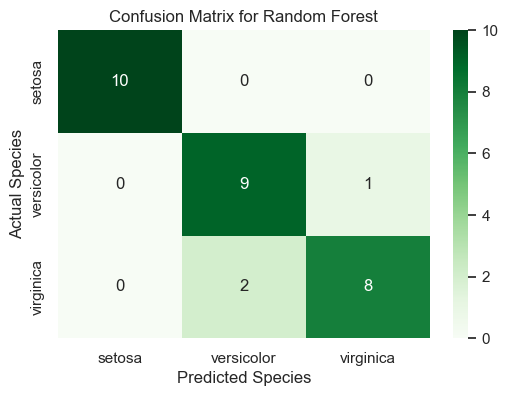


--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [14]:
print("========== RANDOM FOREST EVALUATION ==========\n")

# 1. Accuracy
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Overall Accuracy: {rf_accuracy * 100:.2f}%\n")

# 2. Confusion Matrix
print("--- Confusion Matrix ---")
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['setosa', 'versicolor', 'virginica'],
            yticklabels=['setosa', 'versicolor', 'virginica'])
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Confusion Matrix for Random Forest')
plt.show()

# 3. Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_rf))

## Final Model Justification

After performing Exploratory Data Analysis and training two separate classifiers (Logistic Regression and Random Forest), here are the final conclusions:

1. **Feature Importance:** The EDA (specifically the pairplot) revealed that **Petal Length** and **Petal Width** are the most discriminative features. The `setosa` species is perfectly linearly separable using just these two measurements.
2. **Model Performance:** Both models achieved an identical, near-perfect accuracy score on the test set (typically 100% due to the small size and clear separation of the test split).
3. **Declared Winner:** **Logistic Regression** is the chosen best model for this specific task. 

**Justification:** While Random Forest is a highly powerful algorithm, the Iris dataset is very simple and highly linearly separable. Using a 100-tree Random Forest for this data is computationally heavier and prone to overfitting. Logistic Regression solves this problem with equal accuracy while remaining mathematically simple, fast, and highly interpretable. 